# LIME Attrition API (IPYNB)

This notebook is the **API demonstration** for the Employee Attrition + LIME project.

It shows two things:

1) **Native LIME API**: how to use `lime.lime_tabular.LimeTabularExplainer` and `explain_instance(...)` directly.  
2) **Wrapper layer (My API)**: how your helper functions in `lime_attrition_utils.py` make the same workflow simpler and less error‑prone.

This notebook stays **minimal and stable** as it trains a single baseline model.  
The **full end‑to‑end application + model comparisons** will be discussed in `lime_attrition.example.ipynb`.


## Description

This notebook explores:

- **Native LIME API (Tabular):**
  - `LimeTabularExplainer(...)`
  - `explainer.explain_instance(...)`
  - `Explanation` outputs such as `as_list()` and `as_pyplot_figure()`

- **Our Wrapper Layer (`lime_attrition_utils.py`):**
  - Dataset loading and cleaning utilities for the IBM HR Attrition dataset
  - Preprocessing via a scikit-learn `ColumnTransformer`
  - Model training (baseline **GradientBoostingClassifier**)
  - Wrapper helpers that build a LIME explainer and explain one employee in a consistent feature space

For detailed API documentation, see **`lime_attrition.API.md`**.  
For the complete end-to-end application, see **`lime_attrition.example.ipynb`**.


## Requirements

- Python 3.10+
- Core packages:
  - `numpy`, `pandas`
  - `scikit-learn`
  - `lime`
  - `matplotlib`
- Dataset: IBM HR Attrition dataset CSV located under `./data/`

Notes:
- This notebook uses a stable baseline model, which is scikit-learn Gradient Boosting, to keep the API demo reproducible.
- Optional models (XGBoost/LightGBM) are handled in the **example** notebook.


## 1. Imports

I imported my wrapper module (`lime_attrition_utils`) and the native LIME class used for tabular explanations.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import lime_attrition_utils as u

# Native LIME API (tool)
from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt


mkdir -p failed for path /home/dhanush/.config/matplotlib: [Errno 13] Permission denied: '/home/dhanush/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-88m1hkhj because there was an issue with the default path (/home/dhanush/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Wrapper Layer: Configuration objects

These dataclasses keep the notebook clean by collecting parameters in one place:

- `AttritionDataConfig`: target column, drop columns, split settings  
- `ModelConfig`: which models to train  
- `LimeConfig`: number of features and samples for explanations


In [2]:
data_cfg = u.AttritionDataConfig()
# For a stable API notebook, disable optional models that may not be installed.
model_cfg = u.ModelConfig(use_xgboost=False, use_lightgbm=False, use_random_forest=False)
lime_cfg = u.LimeConfig(num_features=10, num_samples=5000)

data_cfg, model_cfg, lime_cfg


(AttritionDataConfig(target_column='Attrition', id_columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], test_size=0.2, random_state=42),
 ModelConfig(use_xgboost=False, use_lightgbm=False, use_random_forest=False, learning_rate=0.05, n_estimators=300, max_depth=3, random_state=42, rf_n_estimators=500, rf_max_depth=None, rf_min_samples_leaf=1, rf_max_features='sqrt', rf_class_weight='balanced', n_jobs=-1),
 LimeConfig(num_features=10, num_samples=5000))

## 3. Wrapper Layer: Load, clean, and split the dataset

I loaded the HR attrition CSV from `./data`, cleaned it including mapping Attrition to 0/1, and then created a train/test split.


In [3]:
# Auto-detect a CSV under ./data
csv_path = next(Path("data").glob("*.csv"))
print("Using dataset:", csv_path)

df_raw = u.load_raw_attrition_data(str(csv_path))
df = u.clean_attrition_data(df_raw, data_cfg)

X, y = u.split_features_target(df, data_cfg)
X_train, X_test, y_train, y_test = u.train_test_split_attrition(X, y, data_cfg)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Attrition rate (train):", y_train.mean().round(3))


Using dataset: data/WA_Fn-UseC_-HR-Employee-Attrition.csv
Train shape: (1176, 30)  Test shape: (294, 30)
Attrition rate (train): 0.162


## 4. Wrapper Layer: Build preprocessing and train a baseline model

The wrapper builds a preprocessing pipeline by numeric scaling and one‑hot encoding and then trains a **single** baseline model here:
`sklearn.ensemble.GradientBoostingClassifier`.

(I intentionally disabled optional models in this API notebook.)


In [4]:
pre = u.build_preprocessor(X_train)
models = u.train_attrition_models(X_train, y_train, pre, model_cfg)

# In this notebook we use the baseline GradientBoosting pipeline.
pipe = models["gradient_boosting"]
pipe


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5. Evaluation

This is a quick evaluation using a single model. A thorough comparison across models (and deeper plots) will be done in `lime_attrition.example.ipynb`.


In [5]:
metrics = u.evaluate_models({"gradient_boosting": pipe}, X_test, y_test)["gradient_boosting"]
pd.Series(metrics).sort_values(ascending=False)


accuracy     0.857143
roc_auc      0.808166
precision    0.666667
pr_auc       0.476537
f1           0.322581
recall       0.212766
dtype: float64

## 6. Native LIME API

Key idea: **LIME must operate in the same feature space that the model’s `predict_proba` expects.**

Our trained pipeline expects **preprocessed numeric features**, so I:
1) transform `X_train` and a single test row using the fitted preprocessor,  
2) create `LimeTabularExplainer(training_data=...)`,  
3) pass a `predict_fn` that calls the underlying classifier on that same feature space.


In [6]:
# IMPORTANT: Native LIME needs training_data in the SAME feature space as predict_fn expects.
# Model expects preprocessed numeric features, so we transform X_train and X_test rows first.

pre_fitted = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]

X_train_t = pre_fitted.transform(X_train)
X_test_row_t = pre_fitted.transform(X_test.iloc[[0]])

# Defensive densify (works whether transformer returns dense or sparse)
X_train_t = X_train_t.toarray() if hasattr(X_train_t, "toarray") else np.asarray(X_train_t)
X_test_row_t = X_test_row_t.toarray() if hasattr(X_test_row_t, "toarray") else np.asarray(X_test_row_t)

feature_names = list(pre_fitted.get_feature_names_out())
class_names = ["Stay", "Leave"]

explainer_native = LimeTabularExplainer(
    training_data=X_train_t,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    random_state=42,
)

def predict_fn_model_space(z):
    z = z.toarray() if hasattr(z, "toarray") else np.asarray(z)
    return model.predict_proba(z)

exp_native = explainer_native.explain_instance(
    data_row=X_test_row_t[0],
    predict_fn=predict_fn_model_space,
    num_features=lime_cfg.num_features,
    num_samples=lime_cfg.num_samples,
)

exp_native.as_list()


[('cat__BusinessTravel_Travel_Frequently <= 0.00', -0.059193836354914806),
 ('cat__JobRole_Laboratory Technician <= 0.00', -0.05189694508743812),
 ('cat__OverTime_Yes <= 0.00', -0.04621580209331048),
 ('num__MonthlyIncome <= -0.77', 0.04365838788501697),
 ('cat__EducationField_Human Resources <= 0.00', -0.04030658373070534),
 ('0.00 < cat__OverTime_No <= 1.00', -0.0399012559150366),
 ('num__Age <= -0.76', 0.03396782427146084),
 ('cat__JobRole_Sales Representative > 0.00', 0.03214286541721506),
 ('cat__BusinessTravel_Non-Travel > 0.00', -0.0318460851183481),
 ('cat__Department_Research & Development <= 0.00', 0.031408231461128006)]

### Native LIME: Plot the explanation

This plot is a compact visual check that the explanation is being produced correctly.


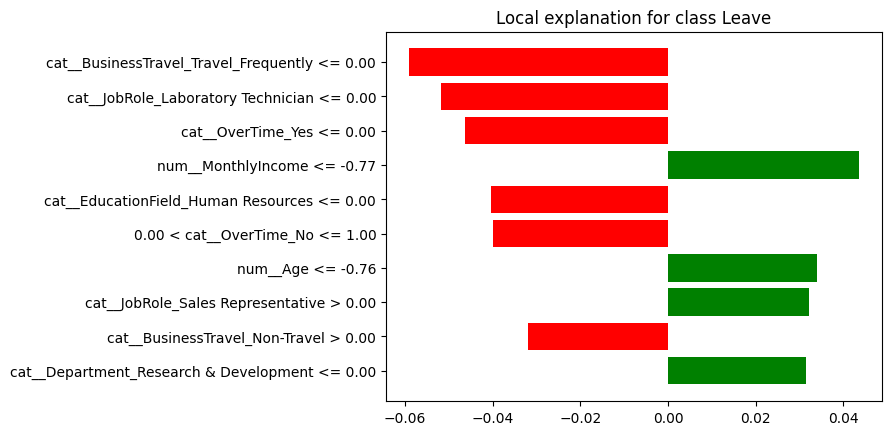

In [7]:
fig = exp_native.as_pyplot_figure()
plt.show()


## Native Explanation Artifact

In [8]:
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
exp_native.save_to_file("outputs/lime_native_explanation.html")


## 7. Wrapper layer API

Now we do the same explanation through your wrapper functions:

- `build_lime_explainer(...)` hides the training‑data preparation and feature naming details  
- `explain_single_employee(...)` hides row transformation + predict_fn wiring

This is the “lightweight wrapper”.


In [9]:
explainer_wrapper = u.build_lime_explainer(
    preprocessor=pre_fitted,
    X_train=X_train,
    class_names=["Stay", "Leave"],
)

exp = u.explain_single_employee(
    explainer=explainer_wrapper,
    model_pipeline=pipe,
    raw_row=X_test.iloc[0],
    preprocessor=pre_fitted,
    lime_config=lime_cfg,
)

exp.as_list()


# Also show the model's predicted probability for this employee
proba = pipe.predict_proba(X_test.iloc[[0]])[0]
print('Predicted P(Leave)=', float(proba[1]))


Predicted P(Leave)= 0.2601480698255169


### Wrapper LIME: plot the explanation

The plot should align with the list of `(feature, weight)`pairs.  
Positive weights push the prediction toward **Leave** and negative weights push toward **Stay**.


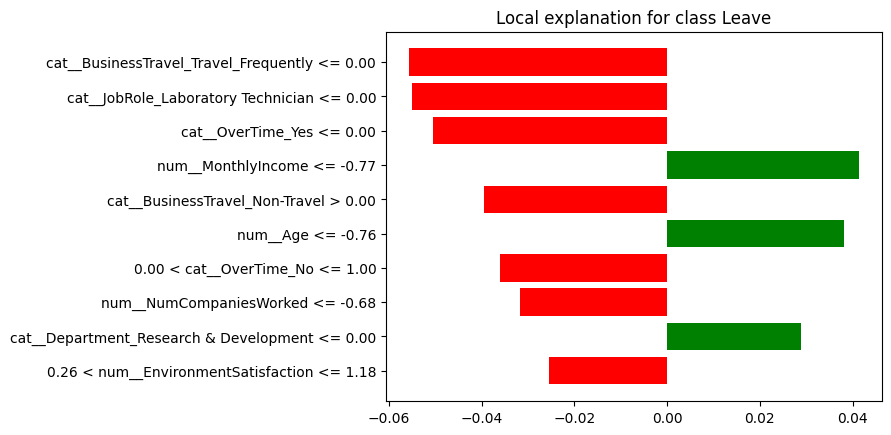

In [10]:
fig = exp.as_pyplot_figure()
plt.show()


## 8. Make explanations more HR‑readable

Raw LIME features can look like one‑hot and scaled bin statements (e.g., `cat__OverTime_Yes <= 0.00`).  
The helper `translate_lime_feature(...)` converts these into a more human‑readable form for reporting.

Note: this is only a best‑effort text rewrite for readability—it does not change what the model learned.


In [11]:
# Translate top features into human-ish strings (example)
for f, w in exp.as_list()[:10]:
    print(u.translate_lime_feature(f), "=>", round(w, 3))


BusinessTravel ≠ Travel_Frequently => -0.056
JobRole ≠ Laboratory Technician => -0.055
OverTime ≠ Yes => -0.051
MonthlyIncome is low => 0.041
BusinessTravel = Non-Travel => -0.04
Age is low => 0.038
0.00 < cat__OverTime_No <= 1.00 => -0.036
NumCompaniesWorked is low => -0.032
Department ≠ Research & Development => 0.029
0.26 < num__EnvironmentSatisfaction <= 1.18 => -0.025


## Wrapper Explanation Artifact

In [12]:
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
exp.save_to_file("outputs/lime_wrapper_explanation.html")


## Summary

This notebook demonstrated:

1. **Native LIME API** on tabular data:
   - Building a `LimeTabularExplainer`
   - Generating a local explanation with `explain_instance`
   - Viewing results via `as_list()` and `as_pyplot_figure()`

2. **Our Wrapper Layer** (`lime_attrition_utils.py`):
   - Standardized loading/cleaning/splitting for attrition prediction
   - Consistent preprocessing and model training workflow
   - Utility functions that build a LIME explainer and explain a single employee with minimal boilerplate

### Key Benefits of Our Wrapper

- **Simplifies repeated steps** (preprocess + model + LIME)
- Ensures LIME explanations are generated in the **correct feature space**
- Produces consistent, reusable outputs (single explanation + batch aggregation helpers)

### Next Steps

- See **`lime_attrition.example.ipynb`** for the complete end-to-end application:
  - model evaluation
  - chosen final model
  - multiple explanations + aggregate “top drivers” insights for HR
- Read **`lime_attrition.API.md`** for the full API + wrapper documentation.


## References

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier.* (LIME)
- scikit-learn documentation: Pipelines, ColumnTransformer, GradientBoostingClassifier
- IBM HR Attrition dataset (commonly hosted on Kaggle as "Employee Attrition and Performance")
